In [1]:
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from typing import TypedDict,Annotated, List
from pydantic import Field,BaseModel
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import operator
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode
from typing import Optional
from datetime import datetime, time, timezone
import re
import serpapi
import os

In [2]:
class TravelState(TypedDict):
    user_input: str = Field(description="Latest user query or message related to travel planning.")
    source: str = Field(description="Departure city or location provided by the user (e.g., Indore, DEL).")
    destination: str = Field(description="Arrival city or destination where the user wants to travel (e.g., Pune, BOM).")
    date_from: str = Field(description="Start date of the trip in YYYY-MM-DD or natural language format.")
    date_to: str = Field(description="End date of the trip in YYYY-MM-DD or natural language format.")
    budget: int = Field(default=0,description="Total budget for the trip in INR. Should be normalized (e.g., '10k' -> 10000).")
    missing_val: List[str] = Field(default_factory=list, description="List of missing required fields among source, destination, date_from, date_to, and budget.")
    missing_question: str = Field(description="Clarification question generated to ask the user for missing trip details.")
    missing_response: str = Field(description="User's response to the clarification question, used to update missing fields.")
    history: Annotated[list, operator.add]
    history_summary:str=""
    tools: list
    output: str = Field(description="Final output")

In [3]:
class ParseSchema(BaseModel):
    source: str
    destination: str
    date_from: str
    date_to: str
    missing_val: list[str] = []
    budget: Optional[int] = Field(default=None)


In [4]:
load_dotenv()

small_model = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0,  max_tokens=2000)
versatile_model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.6)
summarizer_model=ChatGroq(model="llama-3.1-8b-instant",temperature=0.5, max_tokens=2000)
check_model = small_model.with_structured_output(ParseSchema, method="json_schema")

In [5]:
search_tool=DuckDuckGoSearchRun()

def flight_tool(source: str, destination: str, date: str):
    """
    Search for available flights between two locations on a given date.

    Args:
        source (str): Departure airport IATA code (MUST be a 3-letter IATA code, e.g., "IDR" for Indore, "DEL" for Delhi).
        destination (str): Arrival airport IATA code (MUST be a 3-letter IATA code, e.g., "GOI" for Goa, "BOM" for Mumbai).
        date (str): Travel date in YYYY-MM-DD format.

    Returns:
        dict: A dictionary containing:
            - status (str): "success" or "error"
            - data (list): List of best available flights
    """
    SERPAPI_KEY = os.getenv("SERPAPI_KEY")
    client = serpapi.Client(api_key=SERPAPI_KEY)
    try:
        results = client.search({
            "engine": "google_flights",
            "departure_id": source,
            "currency": "INR",
            "type": "2",
            "outbound_date": date,
            "arrival_id": destination
        })
        best_flights = results.get("best_flights", [])[:5]
        return best_flights
    except Exception as e:
        return f"Error executing flight_tool. This often happens if the travel date is in the past or the IATA codes are invalid. Details: {e}"


def _serpapi_depart_at(date: str):
    try:
        travel_date = datetime.strptime(date[:10], "%Y-%m-%d").date()
        depart_time = datetime.combine(travel_date, time(8, 0), tzinfo=timezone.utc)
        return f"depart_at:{int(depart_time.timestamp())}"
    except Exception:
        return None


def train_tool(source: str, destination: str, date: str = ""):
    """
    Search train-preferred public transport routes using SerpApi Google Maps Directions.

    This is useful when the user asks for trains or cheaper intercity transport. It accepts
    normal place names such as "Indore" and "Ahmedabad"; station codes are not required.

    Args:
        source (str): Departure city, station, or address.
        destination (str): Arrival city, station, or address.
        date (str): Travel date in YYYY-MM-DD format. Optional but recommended.

    Returns:
        list | dict: Train/transit route options from Google Maps Directions via SerpApi.
    """
    SERPAPI_KEY = os.getenv("SERPAPI_KEY")
    client = serpapi.Client(api_key=SERPAPI_KEY)
    params = {
        "engine": "google_maps_directions",
        "start_addr": source,
        "end_addr": destination,
        "travel_mode": "3",
        "prefer": "train",
        "gl": "in",
        "hl": "en",
        "distance_unit": "0",
    }
    depart_at = _serpapi_depart_at(date)
    if depart_at:
        params["time"] = depart_at

    try:
        results = client.search(params)
        directions = results.get("directions", [])
        if directions:
            return directions[:5]
        return {
            "message": "No train-preferred route found. Try nearby railway stations or use DuckDuckGo for IRCTC/train-number research.",
            "metadata": results.get("search_metadata", {}),
        }
    except Exception as e:
        return f"Error executing train_tool. Check source/destination names, date, and SERPAPI_KEY. Details: {e}"


tools = [flight_tool, train_tool, search_tool]
tool_node = ToolNode(tools, messages_key="history")


In [6]:
model_with_tools = versatile_model.bind_tools(tools)

In [7]:
def user_input(state:TravelState):
    user=input("Enter your travel details:")

    return {"user_input":user,"history":[HumanMessage(user)]}

In [8]:
def parse_input_llm(state: TravelState):
    system_prompt = f"""You are an information extraction assistant.

Your task is to read the user_input string and extract these fields:
- source: str
- destination: str
- date_from: str
- date_to: str
- budget: int (optional)
- missing_val: list[str]

Rules:
1. Extract only information explicitly present in the user input.
2. If a string field is not found, set it to "". If an integer field like budget is not found, set it to null.
3. missing_val must contain the names of all fields that are "" or null.
4. If budget is mentioned with words like "10k", convert it to an integer (10000).
5. If dates are mentioned in natural language, convert them to a clear string format with YYYY-MM-DD.
6. Return ONLY valid JSON.
7. Do not include any extra text.
8. Assume year as 2026 year if not mentioned explicitly.
9. If no missing values just return empty list.
10. budget must be a number or None.
11. Do NOT return "null" as a string.
12. If the destination is a state, keep the state name as destination; do not invent one city during parsing.
13. If the user gives a start date plus a duration like "3 days", calculate date_to as the final trip date inclusive.
14. If the user do not gives any return date assume it to be missing.
Output format:
{{
  "source": "",
  "destination": "",
  "date_from": "",
  "date_to": "",
  "budget": null,
  "missing_val": []
}}
NOTE: Read history if necessary to find the useful fields from the previous conversation or any update   

History:
{state.get('history', [])}
"""
    res = check_model.invoke([SystemMessage(system_prompt), HumanMessage(state["user_input"])])
    return {
        "source": res.source, 
        "destination": res.destination, 
        "date_from": res.date_from, 
        "budget": res.budget, 
        "date_to": res.date_to, 
        "missing_val": res.missing_val
    }

In [9]:
def missing_check_router(state:TravelState):
    print("--- Executing: missing_check_router ---")
    if(len(state['missing_val'])>0):
        return "ask_missing"
    return "decision_llm"


def ask_missing(state: TravelState):
    print("--- Executing: ask_missing ---")
    prompt = f"""You are a helpful travel assistant.

Your task is to ask the user for missing information required to plan a trip.

Missing fields will be provided as a list:
- source
- destination
- date_from
- date_to
- budget

Rules:
1. Ask ONLY for the missing fields.
2. If multiple fields are missing, combine them into a single natural question.
3. Keep the question short, clear, and conversational.
4. Do NOT mention field names like "date_from" or "date_to" — use natural language.
5. If dates are missing, ask for travel dates together.
6. If budget is missing, ask politely for budget range.
7. Do not ask for fields that are already provided.
8. Return ONLY the question (no JSON, no explanation).

Now generate the question based on:
Missing fields: {state.get('missing_val', [])}"""
    
    res = small_model.invoke(prompt)
    
    return {"missing_question": res.content, "history": [AIMessage(res.content)]}



def update_input(state: TravelState):
    print("--- Executing: update_input ---")
    question = state["missing_question"]
    user = input(question)
    prompt = f"""
You are a travel assistant that updates and summarizes trip details from conversation history.

You are given:
1. Previously extracted trip data
2. A new user response answering missing questions

Your task:
Merge the new response into the previous data and return a COMPLETE, clean, human-readable summary of the trip.

Fields to track:
- source
- destination
- date_from
- date_to
- budget

Rules:
1. Keep all previously filled values unless the user explicitly changes them.
2. Extract any new information from the latest user response.
3. If the user corrects a value, overwrite the old one.
4. Do not remove valid existing data.
5. Convert budget like "10k" -> 10000.
6. Normalize dates into a clear readable format.

Output:
- Return a COMPLETE sentence or paragraph describing the trip.
- Include all available details.
- If something is still missing, clearly mention it.

Input:
Previous data:
{state.get('history', [])[-3:]}

New user response:
{user}
"""
    
    res = small_model.invoke(prompt).content
    
    return {
        "user_input": res, 
        "history": [HumanMessage(res)],
        "missing_question": "",
        "missing_val": [],
        "missing_response": ""
    }

In [10]:
BUDGET_WARNING = "WARNING: The requested itinerary exceeds your budget. Please consider increasing your budget or shortening the trip to optimize this further."


def _extract_inr_amount(text: str, label: str):
    pattern = rf"{label}\s*[:\-]?\s*(?:INR|₹|Rs\.?\s*)?\s*([0-9][0-9,]*)"
    match = re.search(pattern, text, flags=re.IGNORECASE)
    if not match:
        return None
    return int(match.group(1).replace(",", ""))


def _fix_budget_warning(output: str, budget):
    if budget in (None, "", 0):
        return output

    try:
        budget = int(budget)
    except Exception:
        return output

    total = _extract_inr_amount(output, "Total")
    if total is None:
        total = _extract_inr_amount(output, "Estimated Total")
    if total is None:
        return output

    cleaned_output = re.sub(
        rf"^\s*{re.escape(BUDGET_WARNING)}\s*\n+",
        "",
        output,
        flags=re.IGNORECASE,
    )

    if total > budget:
        return cleaned_output if cleaned_output.startswith(BUDGET_WARNING) else f"{BUDGET_WARNING}\n\n{cleaned_output}"

    return cleaned_output


In [11]:
def initial_summary(state: TravelState):
    print("----INITIAL SUMMARY----")
    history = state.get("history", [])
    recent_history = history[-3:]
    prompt = """You are a memory initialization component of a travel planning AI system.

Your task is to create the FIRST structured summary of the conversation. Use natural language to produce a summary with all the important informations.  
Rules:
- Keep it concise (under 150 tokens)
- Do NOT include raw history
- Do NOT repeat conversation
- Do NOT write long summary just the important and main points that covers all the relevant details for the trip
"""

    res = summarizer_model.invoke([
        SystemMessage(prompt),
        HumanMessage(f"Recent Messages:\n{recent_history}")
    ]).content
    return {"history_summary": res}

In [12]:
def summarizer(state:TravelState):
    prompt = """
You are a memory compression component of a travel planning AI.

Update the existing summary using ONLY the new messages. Use natural language to produce a summary with all the important informations. Suggest gaps and actions to execute to fix those gaps.

Rules:
- Keep it concise (under 150-200 tokens)
- Do NOT include raw tool outputs
- Do NOT repeat unnecessary info
- Do NOT write long summary just the important and main points that covers all the relevant details for the trip

"""
    prev_summary = state.get("history_summary", "")
    history = state.get("history", [])
    recent_history = history[-3:]
    recent_text = "\n".join([str(m)[:300] for m in recent_history])
    res = summarizer_model.invoke([
        SystemMessage(prompt),
        HumanMessage(f"""
        Previous Summary:
        {prev_summary}
        
        New Messages:
        {recent_text}
        """)
    ]).content

    return {"history_summary":res}

In [13]:
def decision_llm(state: TravelState):
   print("--- Executing: decision_llm ---")
   summary=state["history_summary"]

   prompt = f""""You are an intelligent and professional travel planning assistant.

Your task is to analyze the user's request along with the current trip details and decide the next best action.

CURRENT TRIP DETAILS:-
{summary}

USER QUERY:-
{state.get('user_input', '')}

AVAILABLE TOOLS:-
- flight_tool: Use to find flights between cities with price, duration, and timing
- train_tool: Use to find train-preferred public transport routes between cities/stations using SerpApi Google Maps Directions
- duckduckgo_search: Use to find tourist places, attractions, activities, and general travel recommendations


YOUR RESPONSIBILITIES

You must strictly choose ONE of the following actions:

### 1. CALL A TOOL
If all required details are available but you need external data:
- If destination appears to be a state/region, first use duckduckgo_search to identify the most important tourist cities, practical route order, and must-see places for the exact trip length.
- Use duckduckgo_search for hotels, attraction timings, entry fees, local transport, food areas, and latest tourist recommendations.
- Use train_tool when the user asks for trains, cheaper transport, or when train is a practical intercity option.
- Use flight_tool only when flights are requested or clearly better for the route.
Rules: Call ONLY ONE tool at a time. Do NOT generate final answer while calling a tool.

### 2. GENERATE FINAL ITINERARY
If tools are completed, generate the COMPLETE itinerary. Check if it fits within the user's total budget of {state.get("budget", "")}. Add the budget warning ONLY when your calculated Total is greater than the user's budget. If Total is less than or equal to the budget, NEVER add a budget warning.

QUALITY RULES FOR REFINED OUTPUT:
- Never give a generic itinerary like "visit local attractions". Name exact cities, neighborhoods/areas, attractions, food stops, transfer points, and approximate time blocks.
- For a state destination, choose the best cities for the available days instead of trying to cover everything. Explain what you skipped and why.
- Build a logical route with minimal backtracking from the user's source.
- Include day-by-day timing: morning, afternoon, evening, night, plus intercity transfer time where relevant.
- Include practical notes: opening/closing constraints when known, local commute mode, approximate costs in INR, and booking advice.
- If a tool result is incomplete, say what is approximate instead of pretending it is confirmed.

Include:
1. Travel Summary (Source -> Destination, dates)
2. Recommended Route (cities in order, especially if destination is a state)
3. Transportation (Best flight/train/road option, price, duration, and why it fits)
4. Accommodation (suggested area plus approx hotel prices)
5. Detailed Day-wise Plan with exact places and time blocks
6. Food and local experience suggestions
7. Budget Summary (Transport + Stay + Food + Local travel + Activities + Total + Remaining)
8. Best transport to travel within each city
9. Use currency as Rupee.
10. Suggest few options related to Hotels.

OUTPUT RULES:
- If calling tool -> return ONLY tool call
- If generating itinerary -> return clean, structured text

Be clear, concise, and helpful."""
    
   messages = [SystemMessage(content=prompt)] + state.get("history", [])
    
   res = model_with_tools.invoke(messages)

   if res.tool_calls:
      return {"history": [res]}
   else:
      output = _fix_budget_warning(res.content, state.get("budget"))
      return {"output": output, "history": [AIMessage(output)]}

In [14]:
def generate_itinerary(state: TravelState):
    print("--- Generating Final Itinerary ---")

    summary = state.get("history_summary", "")
    budget = state.get("budget", "")

    prompt = f"""
You are an expert travel planner.

Using the collected information below, generate a complete travel itinerary.

Trip Details:
{summary}

User Budget: ₹{budget}

Include:
1. Travel Summary
2. Route (cities in order)
3. Transportation (best option with price & duration)
4. Accommodation (areas + price range)
5. Day-wise plan (morning/afternoon/evening/night)
6. Food & local experiences
7. Budget breakdown (transport + stay + food + total)
8. Local transport suggestions

Rules:
- Be specific (no generic suggestions)
- Stay within budget
- Use INR
"""

    res = versatile_model.invoke([
        SystemMessage(content=prompt)
    ])

    return {
        "output": res.content
    }

In [15]:
def check_tools(state):
    print("--- Executing: check_tools ---")

    last_message = state.get("history", [])[-1] if state.get("history") else None

    # ✅ safe increment
    if getattr(last_message, "tool_calls", None):
        state["tool_calls"] = state.get("tool_calls", 0) + 1

        # ✅ HARD LIMIT
        if state["tool_calls"] >= 4:
            return "generate_itinerary"

        return "need_tool"

    return "generate_itinerary"

In [16]:
state_graph = StateGraph(TravelState)

# Nodes
state_graph.add_node("user_input", user_input)
state_graph.add_node("parse_input_llm", parse_input_llm)
state_graph.add_node("ask_missing", ask_missing)
state_graph.add_node("update_input", update_input)
state_graph.add_node("decision_llm", decision_llm)
state_graph.add_node("tool_node", tool_node)
state_graph.add_node("summarizer", summarizer)
state_graph.add_node("initial_summary", initial_summary)
state_graph.add_node("generate_itinerary", generate_itinerary)

# Start flow
state_graph.add_edge(START, "user_input")
state_graph.add_edge("user_input", "parse_input_llm")

# Missing info handling
state_graph.add_conditional_edges(
    "parse_input_llm",
    missing_check_router,
    {
        "decision_llm": "initial_summary",
        "ask_missing": "ask_missing"
    }
)

state_graph.add_edge("ask_missing", "update_input")
state_graph.add_edge("update_input", "parse_input_llm")

# Summary -> decision
state_graph.add_edge("initial_summary", "decision_llm")

# 🔥 ONLY ONE routing for decision node (IMPORTANT)
state_graph.add_conditional_edges(
    "decision_llm",
    check_tools,
    {
        "need_tool": "tool_node",
        "generate_itinerary": "generate_itinerary"
    }
)

# Tool flow
state_graph.add_edge("tool_node", "summarizer")
state_graph.add_edge("summarizer", "decision_llm")

# Final output
state_graph.add_edge("generate_itinerary", END)

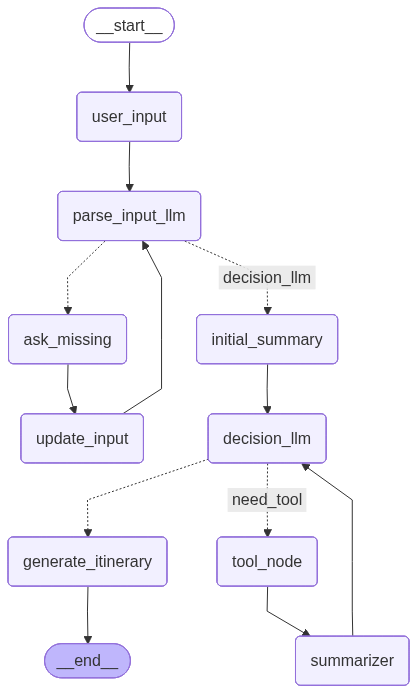

In [17]:
workflow=state_graph.compile()
workflow

In [28]:
res=workflow.invoke({})
res

Enter your travel details:  I want to go to uttrakhand on 3 june with 45k budget and for 4 days from indore with my 8 friends


--- Executing: missing_check_router ---
----INITIAL SUMMARY----
--- Executing: decision_llm ---
--- Executing: check_tools ---
--- Executing: decision_llm ---
--- Executing: check_tools ---
--- Executing: decision_llm ---
--- Executing: check_tools ---
--- Executing: decision_llm ---
--- Executing: check_tools ---
--- Generating Final Itinerary ---


{'user_input': ' I want to go to uttrakhand on 3 june with 45k budget and for 4 days from indore with my 8 friends',
 'source': 'indore',
 'destination': 'uttrakhand',
 'date_from': '2026-06-03',
 'date_to': '2026-06-06',
 'budget': 45000,
 'missing_val': [],
 'history': [HumanMessage(content=' I want to go to uttrakhand on 3 june with 45k budget and for 4 days from indore with my 8 friends', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gck7aea0v', 'function': {'arguments': '{"query":"Uttrakhand 4 day itinerary"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1415, 'total_tokens': 1438, 'completion_time': 0.089553075, 'completion_tokens_details': None, 'prompt_time': 0.113925751, 'prompt_tokens_details': None, 'queue_time': 0.055931209, 'total_time': 0.203478826}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5

In [29]:
print(res['output'])

**Travel Summary:**
Explore the offbeat destinations of Mukteshwar, Munsiyari, and Chaukori in Uttarakhand with a group of 9 people, within a budget of ₹45,000. The 4-day trip will include hidden villages, ancient rock art, serene viewpoints, local crafts, and offbeat adventures.

**Route (cities in order):**
1. Indore
2. Mukteshwar
3. Munsiyari
4. Chaukori

**Transportation:**
The best option for transportation from Indore to Mukteshwar, Munsiyari, and Chaukori is by private bus or tempo traveler, considering the group size and budget. 

- Day 1: Indore to Mukteshwar ( approx. 12 hours, ₹15,000 for a private bus)
- Day 2: Mukteshwar to Munsiyari (approx. 7 hours, ₹8,000 for a private bus)
- Day 3: Munsiyari to Chaukori (approx. 4 hours, ₹4,000 for a private bus)
- Day 4: Chaukori to Indore (approx. 14 hours, ₹18,000 for a private bus)

**Accommodation:**
Book hotels or homestays in the following areas:
- Mukteshwar: Stay in the Dhari area, with a price range of ₹2,000-₹3,000 per night

In [24]:
# I want to go to uttrakhand on 3 june with 20k budget and for 4 days from indore